# Ejercicio: simular y visualizar PAS

Objetivo final: completar un cuaderno como este para generar todas las imágenes del PAS de las diapositivas, subirlo a vuestro perfil de GitHub, y compartirlo conmigo. (Para final de la semana que viene, fecha a concretar).

Sobre el uso de IA generativa / LLMs:
* Se os anima a usarla para desatascaros en pasos pequeños y muy concretos (que te explique cómo hacer la media por filas de una matriz; que te explique cómo funciona cierta función que el profesor ha mencionado etc.).
* Pero no tiene sentido usarla para pasos excesivamente grandes en los que perdéis el control de qué se está haciendo (por ejemplo, decirle que te genere las figuras directamente).
* El verdadero objetivo final es entender el proceso, desarrollar habilidades de planificación, y asimilar las estructuras de pensamiento matemático-computacional subyacentes. Estáis en etapa formativa, no en etapa productiva.
* Como posible control, yo podré convocaros en clase o tutoría para que me expliquéis cómo funciona vuestro código.
* Pero, al fin y al cabo, lo que más está en juego es vuestra formación: adquirir valor añadido (ser capaz de desarrollar unas estructuras mentales que os permitan resolver problemas complejos en el futuro, problemas que quizás sean diferentes a los que hay hoy día), o ser una pieza de poco valor añadido y fácilmente sustituible (un “usuario de IA”).

Se recomienda que avancéis de aquí al lunes. Probablemente le dediquemos lunes y martes, y ya después pasemos a otra cosa. Y tendréis que entregarlo a final de semana (fecha a concretar).

Si escribís sobre este notebook que os comparto, vuestros cambios no se guardarán (porque solo tenéis permisos de lectura). Tendréis que crear una copia vuestra ("Archivo > Guardar una copia en Drive").

---------------------------------------------------------------

In [1]:
import numpy as np
from matplotlib import pyplot as plt

## El núcleo: implementar una función para simular el PAS

Define una función `simular_PAS` que reciba tres argumentos:
* p: este es el parámetro principal del PAS. Es la probabilidad de tomar el valor 1 en cada paso (y la probabilidad de tomar el -1 sería $1-p$). Es un valor entre 0 y 1.
* n: el número de pasos a simular para cada trayectoria. Un número natural.
* reps: el número de trayectorias a simular. Un número natural.

La función debe devolver un array de numpy con dimensionalidad `(reps, n)`, que contenga los valores del PAS en cada paso para cada trayectoria.  

Esqueleto de la función a construir (a completar por vosotros):

In [13]:
def simular_PAS(p,n,reps=1):
  # Input:
  # p: probabilidad de tener +1 con cada paz
  # n: cantidad de pases por trayectoria
  # reps: cantidad de trayectorias
  # Output:
  # output: array de shape (reps, n) que contiene les positiones de PAS

  random_steps = np.random.rand(reps, n) < p

  steps = np.where(random_steps, 1, -1)

  output = np.cumsum(steps, axis=1)

  return output  # Shape: (reps, n)

Primero piensa durante un rato cómo lo harías, e intenta completar la función. Si te quedas atrancado/a, puedes mirar la pista de abajo. **Importante**: lo fundamental de la frase anterior es "*si te quedas atrancado/a*", es decir, debes pensarlo un rato por tu cuenta. De lo contrario, si vas directo a la solución, no se produce ningún aprendizaje y no te sirve de nada.

----------------------------------------

Pista:

En principio, uno podría pensar en incluir dos bucles for:
* uno para iterar sobre las diferentes trayectorias que queremos generar (`reps`),
* otro para iterar sobre los diferentes pasos dentro de cada trayectoria (`n`).

Puedes eliminar ambos bucles construyendo un array de numpy de shape `(reps, n)` que, en cada posición, contenga un $1$ con probabilidad $p$ (y $-1$ con probabilidad $1-p$). Para esto, piensa en usar `np.random.rand` o `np.random.choice`.

Y trabajar ahora con ese array usando herramientas de numpy (piensa qué necesitas hacer con ese array, y busca en internet/LLM herramientas de numpy que hagan eso).


## Visualización 1: diferentes trayectorias del PAS (sin media ni desviación típica teóricas)

Escribir código para crear las imágenes de las diapositivas 16 ($p=0.5$), 17 ($p=0.6$) y 18 ($p=0.4$) del tema 1.

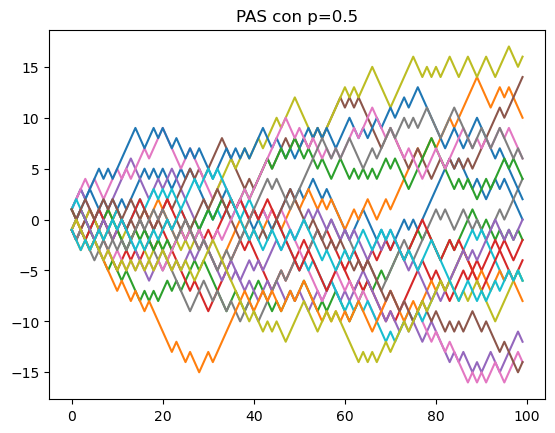

In [17]:
import matplotlib.pyplot as plt

traj = simular_PAS(p=0.5, n=100, reps=20)

for i in range(traj.shape[0]):
    plt.plot(traj[i])

plt.title("PAS con p=0.5")
plt.show()

## Visualización 2: diferentes trayectorias del PAS (con media y desviación típica teóricas)

Escribir código para crear las imágenes de las diapositivas 30 ($p=0.5$), 31 ($p=0.75$), 32 ($p=0.95$) del tema 1.

Para el sombreado de las imágenes, que tiene amplitud $\pm$ 1 o 2 veces la desviación típica, busca en internet/LLM qué función de matplotlib te permite hacerlo.

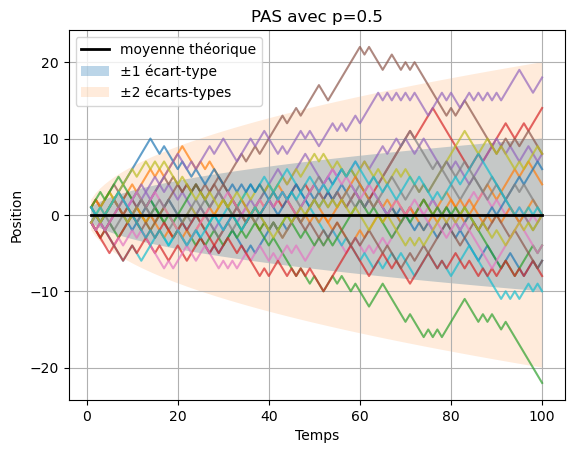

In [20]:
import numpy as np
import matplotlib.pyplot as plt

p = 0.5
n = 100
reps = 20

t = np.arange(1, n + 1)

traj = simular_PAS(p, n, reps)

mean = (2*p - 1) * t
std = np.sqrt(4*p*(1-p) * t)

for i in range(reps):
    plt.plot(t, traj[i], alpha=0.7)

plt.plot(t, mean, color='black', linewidth=2, label='moyenne théorique')
plt.fill_between(t, mean - std, mean + std, alpha=0.3, label='±1 écart-type')
plt.fill_between(t, mean - 2*std, mean + 2*std, alpha=0.15, label='±2 écarts-types')

plt.title(f"PAS avec p={p}")
plt.xlabel("Temps")
plt.ylabel("Position")
plt.legend()
plt.grid(True)
plt.show()

## Visualización 3: visualización de la media empírica del PAS cuando aumentamos el número de trayectorias (junto con la media teórica)

Escribir código para crear la imagen de la diapositiva 35.

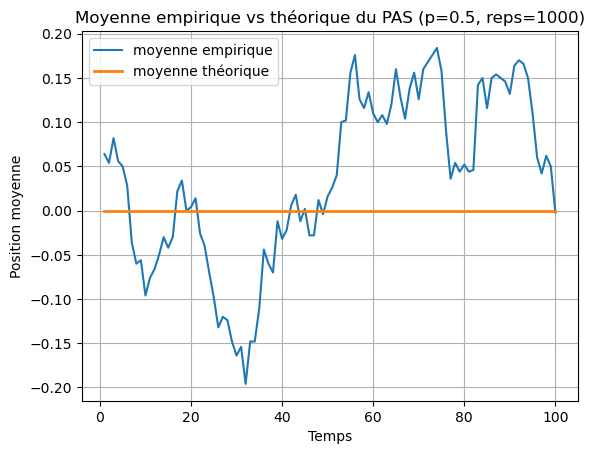

In [22]:
import numpy as np
import matplotlib.pyplot as plt

p = 0.5
n = 100
reps = 1000

t = np.arange(1, n + 1)

traj = simular_PAS(p, n, reps)

empirical_mean = traj.mean(axis=0)
mean = (2*p - 1) * t

plt.plot(t, empirical_mean, label="moyenne empirique")
plt.plot(t, mean, label="moyenne théorique", linewidth=2)

plt.title(f"Moyenne empirique vs théorique du PAS (p={p}, reps={reps})")
plt.xlabel("Temps")
plt.ylabel("Position moyenne")
plt.legend()
plt.grid(True)
plt.show()